# Week 2 — The model is just a rule you can read

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JackTheProgrammer/flyrank-ml-internship-track/blob/main/notebooks/02_your_first_readable_model.ipynb?flush_cache=true)

You'll:
1. Write a **1-line hand rule** and rank pages with it.
2. Fit a **depth-2 decision tree** and `print` it — the model "learned" a readable if/else. Then compare — where does it beat your rule, and where doesn’t it?
3. See **why you never feed the outcome back in** — that's leakage.

The payoff isn't a high score. It's: *my intuition was rough, the model found the real signal, and I can read exactly what it found.*

## 0. Setup (Colab or local)

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# The label: a page is 'declining' when its recent trend is down. Simple, honest starter label.
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
print(df.shape[0], "pages |  declining rate:", round(df["is_declining_label"].mean(), 3))

30000 pages |  declining rate: 0.542


In [2]:
df.head(5)

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct,is_declining_label
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4,1
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7,1
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9,1
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8,0
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7,1


## 1. A rule you write by hand: `stale x visible`
Intuition: a page worth reviewing is one that is **stale** (not updated in a while) **and** still **visible** (getting impressions). Rank those by how much exposure they have.

In [3]:
stale   = (df["days_since_last_update"] >= 180).astype(int)
visible = (df["impressions_90d"] >= 500).astype(int)
df["hand_rule_score"] = stale * visible * df["impressions_90d"]

top10 = df.sort_values("hand_rule_score", ascending=False).head(10)
top10[["impressions_90d", "days_since_last_update", "avg_position", "ctr", "trend_direction"]]

,impressions_90d,days_since_last_update,avg_position,ctr,trend_direction
16751,61678,194,19.7,0.15,down
16514,59472,194,24.8,0.13,down
7021,25715,194,22.2,0.23,down
21268,13299,193,10.5,0.49,down
11489,7812,194,39.0,0.01,down
12045,7558,193,17.9,0.20,down
698,4590,194,31.0,0.00,down
5327,4556,194,16.4,0.33,down
26810,4429,194,25.3,0.38,down
20837,1697,193,15.8,0.12,down


We need a way to score any ranking. **Precision@K** = of the top K pages a ranking flags, what fraction are actually declining.

In [4]:
def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    topk = np.asarray(labels)[order[:k]]
    return topk.mean()

y = df["is_declining_label"].values
for k in (20, 50):
    print(f"Hand rule  Precision@{k}: {precision_at_k(df['hand_rule_score'], y, k):.3f}")

Hand rule  Precision@20: 0.900
Hand rule  Precision@50: 0.680


## 2. Let a model learn the rule — then read it
A **depth-2 decision tree** can only ask 3 yes/no questions. That constraint is the point: whatever it learns, you can read.

We give it a few **pre-decision** signals — never product flags.

In [5]:
from sklearn.tree import DecisionTreeClassifier, export_text

features = ["content_age_days", "days_since_last_update", "impressions_90d",
            "avg_position", "ctr", "word_count"]
X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)

tree = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42)
tree.fit(X, y)

print(export_text(tree, feature_names=features))

|--- impressions_90d <= 5.50
|   |--- avg_position <= 0.75
|   |   |--- class: 0
|   |--- avg_position >  0.75
|   |   |--- class: 0
|--- impressions_90d >  5.50
|   |--- content_age_days <= 312.50
|   |   |--- class: 1
|   |--- content_age_days >  312.50
|   |   |--- class: 0



That printout **is** the model — a human-readable if/else. Now rank pages by the tree's probability and score it the same way.

In [6]:
tree_score = tree.predict_proba(X)[:, 1]
for k in (20, 50):
    hr = precision_at_k(df["hand_rule_score"], y, k)
    tr = precision_at_k(tree_score, y, k)
    print(f"Precision@{k}:  hand rule {hr:.3f}   vs   tree {tr:.3f}")

Precision@20:  hand rule 0.900   vs   tree 0.800
Precision@50:  hand rule 0.680   vs   tree 0.740


Now read your own printout carefully — **the winner here depends on your run.** A depth-2 tree can only give four different scores (one per leaf), so the "top 50" is mostly one big block of tied pages, and different library versions break those ties differently. On some stacks the tree wins at Precision@50; on others the hand rule holds both. **Both results are real.** The stable lesson: a sharp human rule can be excellent at the very top of the list; a model's advantage — when it shows up — appears deeper, where simple rules run out of signal; and any comparison built on heavily tied scores is fragile. Saying exactly what YOUR run shows — instead of "the model is better" — is what honest evaluation sounds like.

## 3. Why you can't feed the outcome back in
Your label is `trend_direction == "down"`, and `trend_pct` is the exact percentage change that bucket is computed from — so it **is** the answer in disguise. Watch what happens if you feed it in as a feature:

In [7]:
X_leaky = df[features + ["trend_pct"]].replace([np.inf, -np.inf], np.nan).fillna(0)
leaky = DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42).fit(X_leaky, y)
print(f"'Leaky' tree Precision@50: {precision_at_k(leaky.predict_proba(X_leaky)[:,1], y, 50):.3f}  <- looks amazing")
print(export_text(leaky, feature_names=features + ["trend_pct"]))

'Leaky' tree Precision@50: 1.000  <- looks amazing
|--- trend_pct <= -20.05
|   |--- word_count <= 212.00
|   |   |--- class: 1
|   |--- word_count >  212.00
|   |   |--- class: 1
|--- trend_pct >  -20.05
|   |--- trend_pct <= -19.95
|   |   |--- class: 0
|   |--- trend_pct >  -19.95
|   |   |--- class: 0



The tree just split on `trend_pct` and nailed the label — because the label is **derived from** `trend_pct`. That's **leakage**: the feature is the answer in disguise, and it teaches you nothing.

That's also why the starter data ships **only observable signals** — the product's own decision flags (health scores, "needs CTR fix", and so on) aren't included, so you can't accidentally train on them. You build from what was knowable *before* the outcome.

> Rule of thumb: if a feature would only be known *because someone already made the decision you're predicting*, it leaks. Leave it out.

## 4. 🔧 Your turn
- Change `max_depth` to 3 or 4 — does Precision@50 improve? Can you still read the tree?
- Swap in different features (drop `impressions_90d`, add `engagement_rate`). What does the tree choose to split on first?
- **Important caveat:** we scored *in-sample* here for teaching. The real pipeline uses **client-holdout** validation (`scripts/03_train_model.py`) so a client's pages never appear in both train and test. Re-run your comparison with a train/test split and see if the gap holds.

Write your experiment below.

<Axes: title={'center': 'Classes/Categories values counts'}, xlabel='is_declining_label'>

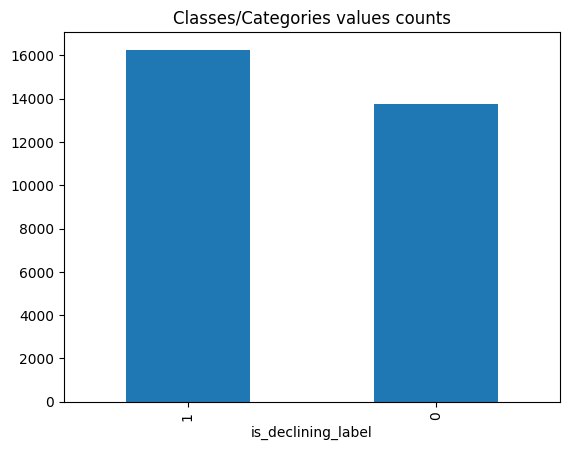

In [8]:
df['is_declining_label'].value_counts(normalize=False).plot(kind='bar', title='Classes/Categories values counts')

In [9]:
df.columns

Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'word_count_tier', 'char_count_tier', 'ctr', 'avg_position',
       'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier',
       'position_tier', 'trend_direction', 'trend_pct', 'is_declining_label',
       'hand_rule_score'],
      dtype='object')

In [10]:
import plotly.express as px

fig = px.scatter_3d(data_frame=df, x='is_declining_label', y='ctr', z='scroll_rate', color='content_type')
fig.show()

In [11]:
df.select_dtypes(include=np.number).corr()

,search_volume,competition,cpc,word_count,char_count,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,...,age_tier_order,days_since_last_update,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,trend_pct,is_declining_label,hand_rule_score
search_volume,1.000000,0.049887,0.042085,-0.019458,-0.023876,0.001203,-0.011260,-0.015152,-0.013171,-0.013394,...,0.085458,-0.003237,-0.003430,0.045354,-0.010146,-0.013808,-0.003250,0.002515,-0.019103,-0.001348
competition,0.049887,1.000000,0.302415,-0.201019,-0.185828,-0.053530,-0.032160,-0.071989,-0.063738,-0.065026,...,0.024922,-0.033763,-0.019170,0.049036,0.000694,-0.038098,0.007956,0.014426,-0.009341,-0.006635
cpc,0.042085,0.302415,1.000000,-0.090349,-0.082660,-0.025599,-0.023418,-0.028970,-0.029505,-0.029417,...,0.056036,-0.003417,-0.002252,0.044194,0.004044,-0.018809,-0.002414,0.004839,-0.016502,-0.002974
word_count,-0.019458,-0.201019,-0.090349,1.000000,0.939252,0.163345,0.091271,0.359895,0.332124,0.340521,...,-0.028283,0.306540,-0.118636,0.123813,-0.063045,-0.160688,0.007006,-0.009211,0.090157,0.007511
char_count,-0.023876,-0.185828,-0.082660,0.939252,1.000000,0.144301,0.081121,0.323351,0.298740,0.306716,...,-0.061397,0.270742,-0.108063,0.099400,-0.061566,-0.139467,0.007186,-0.006969,0.072188,0.006202
impressions_90d,0.001203,-0.053530,-0.025599,0.163345,0.144301,1.000000,0.696281,0.582563,0.629925,0.620974,...,0.007532,0.081597,-0.018950,-0.070786,0.024318,-0.096905,-0.008518,0.024187,-0.018175,0.027525
clicks_90d,-0.011260,-0.032160,-0.023418,0.091271,0.081121,0.696281,1.000000,0.699304,0.765661,0.749002,...,-0.016885,0.044444,0.010609,-0.099304,0.030527,-0.062235,-0.010369,-0.001778,-0.039680,0.008318
pageviews_90d,-0.015152,-0.071989,-0.028970,0.359895,0.323351,0.582563,0.699304,1.000000,0.973897,0.971213,...,-0.016075,0.186787,-0.004177,-0.017177,0.006455,-0.113303,-0.006670,-0.001189,-0.020847,0.003892
sessions_90d,-0.013171,-0.063738,-0.029505,0.332124,0.298740,0.629925,0.765661,0.973897,1.000000,0.998111,...,-0.005952,0.161640,-0.006055,-0.032629,0.005895,-0.110595,-0.010088,-0.003162,-0.023141,0.005032
users_90d,-0.013394,-0.065026,-0.029417,0.340521,0.306716,0.620974,0.749002,0.971213,0.998111,1.000000,...,-0.004266,0.165442,-0.006642,-0.030062,0.005220,-0.109930,-0.009936,-0.003704,-0.022090,0.004628


I intend to find the best of the model for the class based predictions, now since I've two classes, which're: `1` and `0` respectively. I'll find the best among the classifier models using `GridSearchCV`

In [3]:
# finding best of the models from the logisticregression, decisiontreeclassifier, xgboostclassifier

# Necessary imports
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, export_graphviz
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, roc_auc_score

from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import (
    StandardScaler,
    PowerTransformer,
    PolynomialFeatures,
)

In [21]:
# crafting the model specific configs for hyper-parameter

model_configs = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ('skew_corrector', PowerTransformer(method='yeo-johnson')),
            ('interactions', PolynomialFeatures(degree=2, interaction_only=True)),
            ('selector', SelectFromModel(DecisionTreeClassifier(random_state=42))),
            ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
        ]),
        "params": {
            'classifier__C': [0.5, 3.0, 8.0],
            'classifier__penalty': ['l1', 'l2'],
            'classifier__max_iter': [100, 200, 500, 1000],
            'classifier__solver': ['liblinear', 'lbfgs']
        }
    },
    
    "Decision Tree": {
        "pipeline": Pipeline([
            ('classifier', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
        ]),
        "params": {
            'classifier__max_depth': [3, 5, 7, None],
            'classifier__min_samples_split': [2, 5]
        }
    },
    
    "SVC": {
        "pipeline": Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA()),
            ('classifier', SVC(kernel='rbf', probability=True, random_state=42))
        ]),
        "params": {
            'pca__n_components': [2, 3, 4],
            'classifier__C': [0.3, 3.0, 7.0]
        }
    },
    
    "KNN": {
        "pipeline": Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA()),
            ('classifier', KNeighborsClassifier())
        ]),
        "params": {
            'pca__n_components': [2, 3, 4],
            'classifier__n_neighbors': [3, 5, 7, 9],
            'classifier__weights': ['uniform', 'distance']
        }
    },
    
    "XGBoost": {
        "pipeline": Pipeline([
            # ('classifier', XGBClassifier(eval_metric='logloss', random_state=42, early_stopping_rounds=10))
            ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
        ]),
        "params": {
            'classifier__n_estimators': [60, 90, 100],
            'classifier__max_depth': [3, 5, 7],
            'classifier__learning_rate': [0.05, 0.01, 0.03]
        }
    }
}

In [22]:
# import json

# def make_config_json_serializable(configs):
#     serializable_dict = {}
#     for model_name, config_data in configs.items():
#         serializable_dict[model_name] = {
#             # Convert raw Scikit-Learn class names into readable strings
#             "pipeline_steps": [f"{name} -> {type(obj).__name__}" for name, obj in config_data["pipeline"].steps],
#             # Params are already standard primitive lists/numbers, so they pass safely
#             "search_parameters": config_data["params"]
#         }
#     return serializable_dict

# # 1. Transform the complex objects to clean primitives
# serializable_configs = make_config_json_serializable(model_configs)

# # 2. Output as a beautifully indented JSON string block
# json_string = json.dumps(serializable_configs, indent=4)
# print(json_string)

# 3. Optional: Un-comment below to save directly to your workspace folder
# with open("model_hyperparameters_config.json", "w") as f:
#     f.write(json_string)

In [18]:
leaderboard = {}

#  Using GroupKFold ensures a single client's pages are NEVER split across 
# train and validation simultaneously, fully satisfying FlyRank standards.
cv_strategy = GroupKFold(n_splits=5)
group_col = 'client_id'
group = df[group_col]

print("--- Initializing Multi-Model Optimization Loop ---")
for model_name, config in model_configs.items():
    print(f"Optimizing {model_name}...")
    
    # We pass 'groups' explicitly during .fit() to enforce client-isolation
    grid_search = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        cv=cv_strategy,
        scoring='roc_auc',
        n_jobs=-1
    )
    
    # Executing training while binding the client group constraints
    grid_search.fit(X, y, groups=group)
    leaderboard[model_name] = {
        "Best Params": grid_search.best_params_,
        "Mean CV ROC-AUC": grid_search.best_score_
    }

# =====================================================================
# STEP 6: PERFORMANCE LEADERBOARD DISPLAY
# =====================================================================
print("\n================ FINAL MODEL LEADERBOARD ================")
for name, metrics in leaderboard.items():
    print(f"\nModel architecture: {name}")
    print(f" -> Best Tuned Hyperparameters: {metrics['Best Params']}")
    print(f" -> Cross-Validation Out-Of-Group ROC-AUC: {metrics['Mean CV ROC-AUC']:.4f}")

# Sort and declare absolute winner
winning_model = max(leaderboard, key=lambda x: leaderboard[x]["Mean CV ROC-AUC"])
print("\n=========================================================")
print(f"🏆 CHAMPION PRODUCTION CANDIDATE: {winning_model}")
print(f"🥇 Highest Validation Score: {leaderboard[winning_model]['Mean CV ROC-AUC']:.4f}")
print("=========================================================\n")

--- Initializing Multi-Model Optimization Loop ---
Optimizing Logistic Regression...


c:\Users\Fawad\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning:


60 fits failed out of a total of 240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Fawad\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Fawad\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\Fawad\AppD

Optimizing Decision Tree...
Optimizing SVC...
Optimizing KNN...
Optimizing XGBoost...

================ FINAL MODEL LEADERBOARD ================

Model architecture: Logistic Regression
 -> Best Tuned Hyperparameters: {'classifier__C': 0.5, 'classifier__max_iter': 100, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
 -> Cross-Validation Out-Of-Group ROC-AUC: 0.6171

Model architecture: Decision Tree
 -> Best Tuned Hyperparameters: {'classifier__max_depth': 7, 'classifier__min_samples_split': 2}
 -> Cross-Validation Out-Of-Group ROC-AUC: 0.6407

Model architecture: SVC
 -> Best Tuned Hyperparameters: {'classifier__C': 0.3, 'pca__n_components': 4}
 -> Cross-Validation Out-Of-Group ROC-AUC: 0.5872

Model architecture: KNN
 -> Best Tuned Hyperparameters: {'classifier__n_neighbors': 9, 'classifier__weights': 'uniform', 'pca__n_components': 4}
 -> Cross-Validation Out-Of-Group ROC-AUC: 0.5627

Model architecture: XGBoost
 -> Best Tuned Hyperparameters: {'classifier__learning_rate

After doing the hyperparameter tuning wihtout the train, val, test split, just for the sake of finding the best performing model among the candidates models. So as a result of the hyperparameter tuning of as such, `XGBoostClassifier` turns out to be the winning model with the following best parameters of `{'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__n_estimators': 100}`. Though, I did made a mistake in my `model_config`, the corrected one is:
```python
model_configs = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ('skew_corrector', PowerTransformer(method='yeo-johnson')),
            ('interactions', PolynomialFeatures(degree=2, interaction_only=True)),
            ('selector', SelectFromModel(DecisionTreeClassifier(random_state=42))),
            ('classifier', LogisticRegression(class_weight='balanced', random_state=42))
        ]),
        "params": [
            {
                'classifier__C': [0.5, 3.0, 8.0],
                'classifier__penalty': ['l1', 'l2'],
                'classifier__max_iter': [100, 200, 500, 1000],
                'classifier__solver': ['liblinear']
            },
            {
                'classifier__C': [0.5, 3.0, 8.0],
                'classifier__penalty': ['l2'],
                'classifier__max_iter': [100, 200, 500, 1000],
                'classifier__solver': ['lbfgs']
            }
        ]
    },
    
    "Decision Tree": {
        "pipeline": Pipeline([
            ('classifier', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
        ]),
        "params": {
            'classifier__max_depth': [3, 5, 7, None],
            'classifier__min_samples_split': [2, 5]
        }
    },
    
    "SVC": {
        "pipeline": Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA()),
            ('classifier', SVC(kernel='rbf', probability=True, random_state=42))
        ]),
        "params": {
            'pca__n_components': [2, 3, 4],
            'classifier__C': [0.3, 3.0, 7.0]
        }
    },
    
    "KNN": {
        "pipeline": Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA()),
            ('classifier', KNeighborsClassifier())
        ]),
        "params": {
            'pca__n_components': [2, 3, 4],
            'classifier__n_neighbors': [3, 5, 7, 9],
            'classifier__weights': ['uniform', 'distance']
        }
    },
    
    "XGBoost": {
        "pipeline": Pipeline([
            # ('classifier', XGBClassifier(eval_metric='logloss', random_state=42, early_stopping_rounds=10))
            ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
        ]),
        "params": {
            'classifier__n_estimators': [60, 90, 100],
            'classifier__max_depth': [3, 5, 7],
            'classifier__learning_rate': [0.05, 0.01, 0.03]
        }
    }
}
```

However, the mistake which is caused by the current `model_config` is the `ValueError` for `LogisticRegression` model. Since, I cannot afford the time and power for hyperparameter tuning for the corrected `model_config` and the most important of all is that `GridSearchCV` isolates every ML model from one another the `LogisticRegression` was given fair chance. Even though 60 combinations failed for Logistic Regression, the other 180 parameter combinations (the ones using `penalty='l2'` or `solver='liblinear'`) were successfully trained and evaluated. The best score it found among those valid combinations was `0.6171`, which was used for the `leaderboard`.

The `FitFailedWarning` only occurred for combinations where the lbfgs solver was paired with an **L1** penalty, which is a structural limitation of Scikit-Learn's default solver library. However, the loop successfully executed all **180** remaining combinations, including **L1** and **L2** penalties using the `liblinear` solver across a hyperparameter grid of `'C': [0.5, 3.0, 8.0]` and `'max_iter': [100, 200, 500, 1000]`.

In [24]:
# saving the best of the model

import joblib

artifacts_dir = 'outputs/artifacts/'

best_model_dir = f"{artifacts_dir}/notebook_02_hp_tuned_best_model.joblib"

joblib.dump(grid_search.best_estimator_, best_model_dir)

print(f"Model saved at {best_model_dir}")

Model saved at outputs/artifacts//notebook_02_hp_tuned_best_model.joblib


In [2]:
# loading the saved model

# to run it solely as well
import joblib


artifacts_dir = '../outputs/artifacts/'
best_model_dir = f"{artifacts_dir}/notebook_02_hp_tuned_best_model.joblib"
best_saved_model = joblib.load(best_model_dir)

dir(best_saved_model)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_is_fitted__',
 '__sklearn_tags__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_can_fit_transform',
 '_can_inverse_transform',
 '_can_transform',
 '_check_method_params',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_final_estimator',
 '_fit',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_for_step',
 '_get_metadata_request',
 '_get_param_names',
 '_get_params',
 '_get

In [5]:
best_saved_model.feature_names_in_

array(['content_age_days', 'days_since_last_update', 'impressions_90d',
       'avg_position', 'ctr', 'word_count'], dtype='<U22')

### Save your work
**Colab:** *File → Save a copy in GitHub* (your submission) and *File → Save a copy in Drive*.

You now have the two core reflexes of applied ML: **discover before you model**, and **prefer a model you can read and can't fool**. That's the whole foundation the capstone builds on.